BLIND TEST - DECEMBER 2024 DATA
Testing model on completely unseen data from a different month

[1/7] Loading trained model and encoders...
Loading model: xgboost_destination_model_20251002_150024.json
Loading encoders: model_encoders_20251002_150024.pkl
✓ Model loaded successfully
✓ Number of destination classes: 101

[2/7] Selecting 10 random files from December 2024...
Total files available in December: 31

Randomly selected 10 files:
  1. 20241202.csv.out
  2. 20241205.csv.out
  3. 20241222.csv.out
  4. 20241219.csv.out
  5. 20241207.csv.out
  6. 20241217.csv.out
  7. 20241210.csv.out
  8. 20241215.csv.out
  9. 20241208.csv.out
  10. 20241212.csv.out

[3/7] Processing December data with same pipeline...
Loading files...
✓ Loaded 19111218 total records
Cleaning data...
✓ After filtering: 5025377 records
✓ Unique vehicles: 1928
Calculating trip distances...
✓ After distance filtering: 3835421 records

[4/7] Extracting complete trips...
✓ Extracted 118193 complete trips

[5/7] Creatin

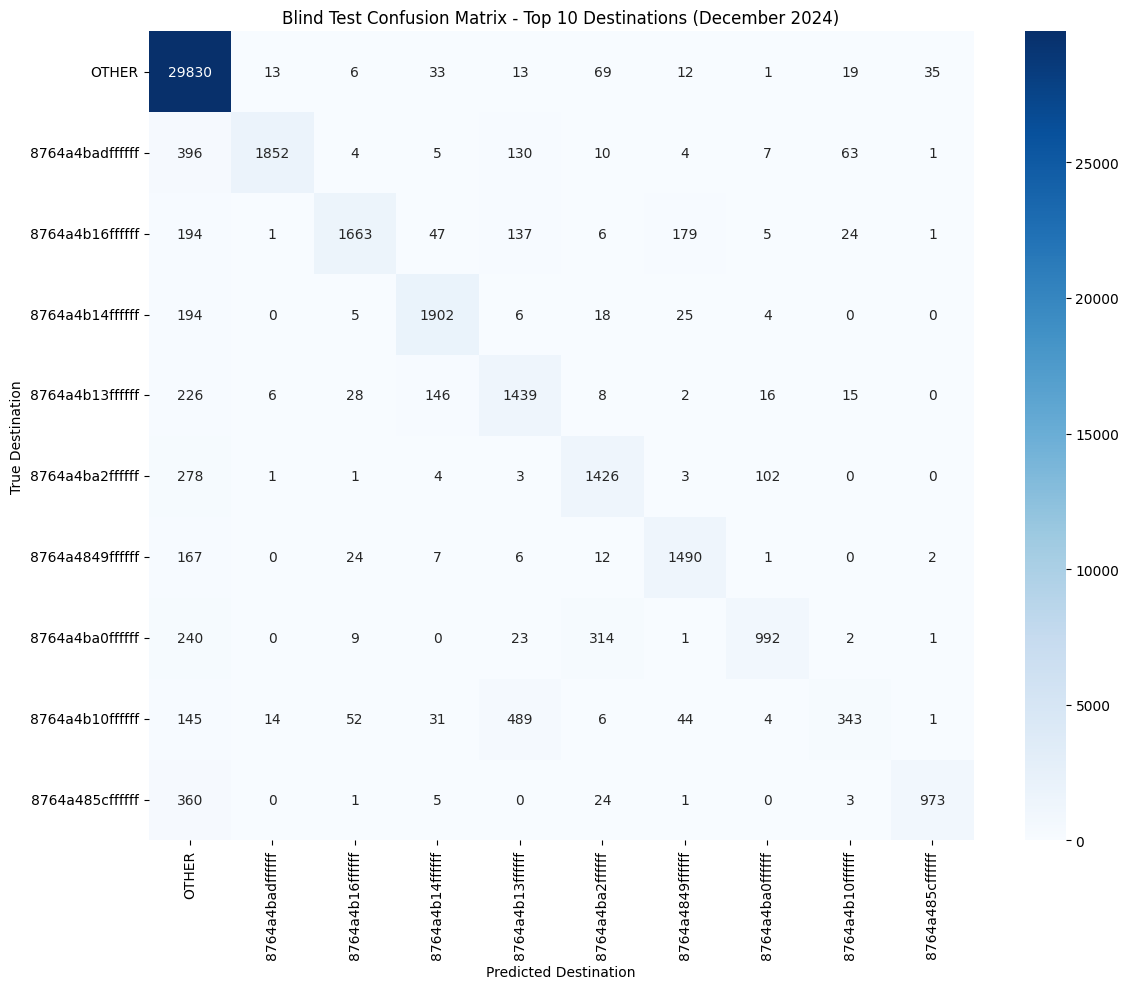

: 

In [ ]:
import pandas as pd
import numpy as np
import os
import h3
import xgboost as xgb
import joblib
from sklearn.metrics import (
    accuracy_score, 
    classification_report,
    top_k_accuracy_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import random
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("BLIND TEST - DECEMBER 2024 DATA")
print("Testing model on completely unseen data from a different month")
print("="*80)

# =====================================================
# CONFIGURATION
# =====================================================
DECEMBER_FOLDER = '/Users/jul/Desktop/uni/Data Analytics/PROBE-202412'
NUM_FILES_TO_TEST = 10
H3_RESOLUTION = 7
MIN_DESTINATION_COUNT = 10

# Bangkok region bounds
BKK_REGION_BOUNDS = {
    'min_lat': 13.4,
    'max_lat': 14.2,
    'min_lon': 99.9,
    'max_lon': 101.3
}

# Column names for raw data
columns = [
    'VehicleID', 'gpsvalid', 'lat', 'lon', 'timestamp',
    'speed', 'heading', 'for_hire_light', 'engine_acc'
]

# =====================================================
# STEP 1: Load Trained Model and Encoders
# =====================================================
print("\n[1/7] Loading trained model and encoders...")

# Find the most recent model files
model_files = [f for f in os.listdir('.') if f.startswith('xgboost_destination_model_') and f.endswith('.json')]
encoder_files = [f for f in os.listdir('.') if f.startswith('model_encoders_') and f.endswith('.pkl')]

if not model_files or not encoder_files:
    raise FileNotFoundError("Model or encoder files not found! Please train the model first.")

# Get the most recent files
model_file = sorted(model_files)[-1]
encoder_file = sorted(encoder_files)[-1]

print(f"Loading model: {model_file}")
model = xgb.Booster()
model.load_model(model_file)

print(f"Loading encoders: {encoder_file}")
encoders_dict = joblib.load(encoder_file)

label_encoders = encoders_dict['label_encoders']
target_encoder = encoders_dict['target_encoder']
feature_names = encoders_dict['feature_names']
top_destinations = encoders_dict['top_destinations']

print(f"✓ Model loaded successfully")
print(f"✓ Number of destination classes: {len(target_encoder.classes_)}")

# =====================================================
# STEP 2: Randomly Select 10 Files from December
# =====================================================
print("\n[2/7] Selecting 10 random files from December 2024...")

all_dec_files = [f for f in os.listdir(DECEMBER_FOLDER) if f.endswith('.csv.out')]
print(f"Total files available in December: {len(all_dec_files)}")

if len(all_dec_files) < NUM_FILES_TO_TEST:
    print(f"⚠️  Only {len(all_dec_files)} files available. Using all of them.")
    selected_files = all_dec_files
else:
    random.seed(42)  # For reproducibility
    selected_files = random.sample(all_dec_files, NUM_FILES_TO_TEST)

print(f"\nRandomly selected {len(selected_files)} files:")
for i, f in enumerate(selected_files, 1):
    print(f"  {i}. {f}")

# =====================================================
# STEP 3: Process December Data (Same Pipeline)
# =====================================================
print("\n[3/7] Processing December data with same pipeline...")

def haversine_distance(lon1, lat1, lon2, lat2):
    """Calculate distance in km between two points."""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return c * 6371

def calculate_total_trip_fees(distance_km):
    """Calculate taxi fare in THB based on distance."""
    if distance_km <= 0:
        return 0
    fare = 35.0
    if distance_km > 1:
        fare += min(distance_km - 1, 9) * 6.50
    if distance_km > 10:
        fare += min(distance_km - 10, 10) * 7.00
    if distance_km > 20:
        fare += min(distance_km - 20, 20) * 8.00
    if distance_km > 40:
        fare += min(distance_km - 40, 20) * 8.50
    if distance_km > 60:
        fare += min(distance_km - 60, 20) * 9.00
    if distance_km > 80:
        fare += (distance_km - 80) * 10.50
    return fare

# Load and process files
print("Loading files...")
all_dfs = []
for filename in selected_files:
    file_path = os.path.join(DECEMBER_FOLDER, filename)
    df = pd.read_csv(file_path, names=columns)
    all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)
print(f"✓ Loaded {len(combined_df)} total records")

# Clean and filter
print("Cleaning data...")
cleaned_df = combined_df.dropna()
cleaned_taxi_df = cleaned_df[
    (combined_df['gpsvalid'] == 1) &
    (combined_df['engine_acc'] == 1) &
    (combined_df['lat'].between(-90, 90)) &
    (combined_df['lon'].between(-180, 180)) &
    (combined_df['speed'] >= 0)
].copy().reset_index(drop=True)

# Identify taxis
taxi_ids = cleaned_taxi_df[cleaned_taxi_df['for_hire_light'] == 1]['VehicleID'].unique()
taxis_df = cleaned_taxi_df[cleaned_taxi_df['VehicleID'].isin(taxi_ids)].copy()

# Convert timestamp and sort
taxis_df['timestamp'] = pd.to_datetime(taxis_df['timestamp'])
taxis_df.sort_values(by=['VehicleID', 'timestamp'], inplace=True)
taxis_df.reset_index(drop=True, inplace=True)

# Extract time features
taxis_df['hour'] = taxis_df['timestamp'].dt.hour
taxis_df['day_of_week'] = taxis_df['timestamp'].dt.dayofweek
taxis_df['is_weekend'] = (taxis_df['day_of_week'] >= 5).astype(int)

# Identify trips
taxis_df['trip_start'] = (taxis_df['for_hire_light'].shift(1) == 1) & \
                          (taxis_df['for_hire_light'] == 0) & \
                          (taxis_df['VehicleID'].shift(1) == taxis_df['VehicleID'])
taxis_df['trip_id'] = taxis_df.groupby('VehicleID')['trip_start'].cumsum()
taxis_df.drop(columns=['trip_start'], inplace=True)

# Filter to Bangkok region
taxis_df_bkk = taxis_df[
    (taxis_df['lat'] >= BKK_REGION_BOUNDS['min_lat']) &
    (taxis_df['lat'] <= BKK_REGION_BOUNDS['max_lat']) &
    (taxis_df['lon'] >= BKK_REGION_BOUNDS['min_lon']) &
    (taxis_df['lon'] <= BKK_REGION_BOUNDS['max_lon']) &
    (taxis_df['speed'] <= 180)
].copy()

print(f"✓ After filtering: {len(taxis_df_bkk)} records")
print(f"✓ Unique vehicles: {taxis_df_bkk['VehicleID'].nunique()}")

# Calculate distances
print("Calculating trip distances...")
taxis_df_bkk['lat_next'] = taxis_df_bkk.groupby(['VehicleID', 'trip_id'])['lat'].shift(-1)
taxis_df_bkk['lon_next'] = taxis_df_bkk.groupby(['VehicleID', 'trip_id'])['lon'].shift(-1)
taxis_df_bkk['segment_distance_km'] = haversine_distance(
    taxis_df_bkk['lon'], taxis_df_bkk['lat'], 
    taxis_df_bkk['lon_next'], taxis_df_bkk['lat_next']
)

trip_distances = taxis_df_bkk.groupby(['VehicleID', 'trip_id'])['segment_distance_km'].sum().reset_index()
trip_distances.rename(columns={'segment_distance_km': 'total_trip_distance_km'}, inplace=True)

taxis_df_bkk = pd.merge(taxis_df_bkk, trip_distances, on=['VehicleID', 'trip_id'], how='left')
taxis_df_bkk = taxis_df_bkk[
    (taxis_df_bkk['total_trip_distance_km'] <= 300) & 
    (taxis_df_bkk['total_trip_distance_km'] > 0)
]

taxis_df_bkk['total_trip_fees'] = taxis_df_bkk['total_trip_distance_km'].apply(calculate_total_trip_fees)

print(f"✓ After distance filtering: {len(taxis_df_bkk)} records")

# =====================================================
# STEP 4: Extract Complete Trips
# =====================================================
print("\n[4/7] Extracting complete trips...")

trips_list = []

for (vehicle_id, trip_id), group in taxis_df_bkk.groupby(['VehicleID', 'trip_id']):
    if trip_id == 0:
        continue
    
    occupied = group[group['for_hire_light'] == 0].copy()
    
    if len(occupied) < 2:
        continue
    
    pickup = occupied.iloc[0]
    dropoff = occupied.iloc[-1]
    
    duration = (dropoff['timestamp'] - pickup['timestamp']).total_seconds() / 60
    
    if duration < 1 or duration > 180:
        continue
    
    trip_record = {
        'VehicleID': vehicle_id,
        'trip_id': trip_id,
        'pickup_lat': pickup['lat'],
        'pickup_lon': pickup['lon'],
        'pickup_timestamp': pickup['timestamp'],
        'dropoff_lat': dropoff['lat'],
        'dropoff_lon': dropoff['lon'],
        'dropoff_timestamp': dropoff['timestamp'],
        'trip_duration_minutes': duration,
        'trip_distance_km': pickup['total_trip_distance_km'],
        'trip_fees_thb': pickup['total_trip_fees'],
        'pickup_hour': pickup['hour'],
        'pickup_day_of_week': pickup['day_of_week'],
        'pickup_is_weekend': pickup['is_weekend']
    }
    
    trips_list.append(trip_record)

trips_df = pd.DataFrame(trips_list)
print(f"✓ Extracted {len(trips_df)} complete trips")

# =====================================================
# STEP 5: Create H3 Zones and Features (REVISED & FINAL)
# =====================================================
print("\n[5/7] Creating H3 zones and engineering features...")

# --- H3 Zoning ---
trips_df['origin_h3'] = trips_df.apply(
    lambda row: h3.latlng_to_cell(row['pickup_lat'], row['pickup_lon'], H3_RESOLUTION),
    axis=1
)
trips_df['destination_h3'] = trips_df.apply(
    lambda row: h3.latlng_to_cell(row['dropoff_lat'], row['dropoff_lon'], H3_RESOLUTION),
    axis=1
)
print(f"✓ Unique origin zones: {trips_df['origin_h3'].nunique()}")
print(f"✓ Unique destination zones: {trips_df['destination_h3'].nunique()}")


# --- Feature Engineering ---

# 1. Date & Time Features
print("Engineering date and time features...")
trips_df['pickup_day'] = trips_df['pickup_timestamp'].dt.day
trips_df['is_rush_hour'] = (
    ((trips_df['pickup_hour'] >= 7) & (trips_df['pickup_hour'] <= 9)) |
    ((trips_df['pickup_hour'] >= 17) & (trips_df['pickup_hour'] <= 20))
).astype(int)

def get_time_period(hour):
    if 6 <= hour < 12: return 'morning'
    elif 12 <= hour < 17: return 'afternoon'
    elif 17 <= hour < 21: return 'evening'
    else: return 'night'
trips_df['time_period'] = trips_df['pickup_hour'].apply(get_time_period)

# Cyclical features
trips_df['hour_sin'] = np.sin(2 * np.pi * trips_df['pickup_hour'] / 24)
trips_df['hour_cos'] = np.cos(2 * np.pi * trips_df['pickup_hour'] / 24)
trips_df['day_sin'] = np.sin(2 * np.pi * trips_df['pickup_day_of_week'] / 7)
trips_df['day_cos'] = np.cos(2 * np.pi * trips_df['pickup_day_of_week'] / 7)
trips_df['day_of_month_sin'] = np.sin(2 * np.pi * trips_df['pickup_day'] / 31)
trips_df['day_of_month_cos'] = np.cos(2 * np.pi * trips_df['pickup_day'] / 31)

# 2. Geographic Features
print("Engineering geographic features...")
BKK_CENTER_LAT, BKK_CENTER_LON = 13.7563, 100.5018
trips_df['distance_from_center_km'] = haversine_distance(
    trips_df['pickup_lon'], trips_df['pickup_lat'], BKK_CENTER_LON, BKK_CENTER_LAT
)
h3_centers = trips_df['origin_h3'].apply(lambda x: h3.cell_to_latlng(x))
trips_df['origin_center_lat'] = h3_centers.apply(lambda x: x[0])
trips_df['origin_center_lon'] = h3_centers.apply(lambda x: x[1])

# 3. Historical Demand Features
print("Engineering historical demand features...")
trips_df['od_pair'] = trips_df['origin_h3'] + '_' + trips_df['destination_h3']

trips_df['zone_historical_trips'] = trips_df.groupby('origin_h3')['trip_id'].transform('count')
trips_df['zone_avg_duration'] = trips_df.groupby('origin_h3')['trip_duration_minutes'].transform('mean')
trips_df['zone_avg_distance'] = trips_df.groupby('origin_h3')['trip_distance_km'].transform('mean') # <-- THIS LINE WAS ADDED
trips_df['od_pair_historical_count'] = trips_df.groupby('od_pair')['trip_id'].transform('count')
trips_df['origin_to_dest_popularity'] = trips_df['od_pair_historical_count'] / trips_df['zone_historical_trips']
trips_df['od_rush_historical_count'] = trips_df[trips_df['is_rush_hour'] == 1].groupby('od_pair')['trip_id'].transform('count')
trips_df['od_timeperiod_historical_count'] = trips_df.groupby(['od_pair', 'time_period'])['trip_id'].transform('count')

# Fill NaNs
fill_cols = [
    'zone_historical_trips', 'zone_avg_duration', 'zone_avg_distance',
    'od_pair_historical_count', 'origin_to_dest_popularity',
    'od_rush_historical_count', 'od_timeperiod_historical_count'
]
trips_df[fill_cols] = trips_df[fill_cols].fillna(0)

print("✓ Feature engineering complete")

# =====================================================
# STEP 6: Prepare Test Data and Make Predictions
# =====================================================
print("\n[6/7] Preparing test data and making predictions...")

# Filter to destinations in training data (Top-N + OTHER)
trips_df['destination_h3_categorized'] = trips_df['destination_h3'].apply(
    lambda x: x if x in top_destinations else 'OTHER'
)

# Only keep trips where destination exists in training classes
valid_destinations = set(target_encoder.classes_)
trips_test = trips_df[trips_df['destination_h3_categorized'].isin(valid_destinations)].copy()

print(f"✓ Test trips with known destination classes: {len(trips_test)}")

if len(trips_test) == 0:
    print("⚠️  ERROR: No test trips with destinations seen during training!")
    print("This could mean December data has completely different travel patterns.")
    exit()

# Prepare features
X_test = trips_test[feature_names].copy()

# Encode categorical features
for col in ['origin_h3', 'time_period']:
    if col in label_encoders:
        le = label_encoders[col]
        X_test[col] = X_test[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else -1
        )

# Encode target
y_test_true = target_encoder.transform(trips_test['destination_h3_categorized'])

# Create DMatrix and predict
dtest = xgb.DMatrix(X_test, feature_names=feature_names)
y_test_pred_proba = model.predict(dtest)
y_test_pred_classes = np.argmax(y_test_pred_proba, axis=1)

print("✓ Predictions complete")

# =====================================================
# STEP 7: Evaluate Performance
# =====================================================
print("\n[7/7] Evaluating model performance on blind test...")

print("\n" + "="*80)
print("BLIND TEST RESULTS - DECEMBER 2024")
print("="*80)

test_acc = accuracy_score(y_test_true, y_test_pred_classes)
print(f"\nTop-1 Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

for k in [3, 5, 10]:
    if k <= len(target_encoder.classes_):
        top_k = top_k_accuracy_score(y_test_true, y_test_pred_proba, k=k)
        print(f"Top-{k} Accuracy:  {top_k:.4f} ({top_k*100:.2f}%)")

f1_macro = f1_score(y_test_true, y_test_pred_classes, average='macro')
f1_weighted = f1_score(y_test_true, y_test_pred_classes, average='weighted')

print(f"\nF1 Score (Macro):    {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Detailed classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT (Top 20 Most Common Destinations)")
print("="*80)

top_20_classes = pd.Series(y_test_true).value_counts().head(20).index.tolist()
mask = np.isin(y_test_true, top_20_classes)

if mask.sum() > 0:
    report = classification_report(
        y_test_true[mask], 
        y_test_pred_classes[mask],
        labels=top_20_classes,
        target_names=[str(target_encoder.classes_[i])[:30] for i in top_20_classes],
        digits=3,
        zero_division=0
    )
    print(report)

# Confusion matrix for top destinations
print("\nGenerating confusion matrix...")
top_10_classes = pd.Series(y_test_true).value_counts().head(10).index.tolist()
mask = np.isin(y_test_true, top_10_classes)

if mask.sum() > 0:
    cm = confusion_matrix(y_test_true[mask], y_test_pred_classes[mask], labels=top_10_classes)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=[str(target_encoder.classes_[i])[:20] for i in top_10_classes],
        yticklabels=[str(target_encoder.classes_[i])[:20] for i in top_10_classes]
    )
    plt.xlabel('Predicted Destination')
    plt.ylabel('True Destination')
    plt.title('Blind Test Confusion Matrix - Top 10 Destinations (December 2024)')
    plt.tight_layout()
    plt.savefig('blind_test_confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("✓ Confusion matrix saved: blind_test_confusion_matrix.png")

# Distribution comparison
print("\n" + "="*80)
print("DATA DISTRIBUTION COMPARISON")
print("="*80)

print("\nTime Period Distribution:")
print(trips_test['time_period'].value_counts())

print(f"\nWeekend trips: {trips_test['pickup_is_weekend'].sum()} ({trips_test['pickup_is_weekend'].sum()/len(trips_test)*100:.1f}%)")
print(f"Rush hour trips: {trips_test['is_rush_hour'].sum()} ({trips_test['is_rush_hour'].sum()/len(trips_test)*100:.1f}%)")

print("\nAverage trip statistics:")
print(f"  Distance: {trips_test['trip_distance_km'].mean():.2f} km")
print(f"  Duration: {trips_test['trip_duration_minutes'].mean():.2f} minutes")
print(f"  Fare: {trips_test['trip_fees_thb'].mean():.2f} THB")

# Save detailed results
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

results_summary = {
    'test_date': 'December 2024',
    'num_files_tested': len(selected_files),
    'num_trips': len(trips_test),
    'top_1_accuracy': test_acc,
    'top_3_accuracy': top_k_accuracy_score(y_test_true, y_test_pred_proba, k=3),
    'top_5_accuracy': top_k_accuracy_score(y_test_true, y_test_pred_proba, k=5),
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'avg_trip_distance_km': trips_test['trip_distance_km'].mean(),
    'avg_trip_duration_min': trips_test['trip_duration_minutes'].mean(),
    'avg_fare_thb': trips_test['trip_fees_thb'].mean()
}

results_df = pd.DataFrame([results_summary])
results_df.to_csv('blind_test_results_summary.csv', index=False)
print("✓ Results summary saved: blind_test_results_summary.csv")

trips_test_with_predictions = trips_test.copy()
trips_test_with_predictions['predicted_destination'] = target_encoder.inverse_transform(y_test_pred_classes)
trips_test_with_predictions['prediction_correct'] = (y_test_true == y_test_pred_classes)

trips_test_with_predictions.to_csv('blind_test_detailed_results.csv', index=False)
print("✓ Detailed results saved: blind_test_detailed_results.csv")

print("\n" + "="*80)
print("BLIND TEST COMPLETE! ✅")
print("="*80)
print(f"\nModel tested on {len(trips_test)} trips from December 2024")
print(f"Top-1 Accuracy: {test_acc*100:.2f}%")
print(f"Top-3 Accuracy: {top_k_accuracy_score(y_test_true, y_test_pred_proba, k=3)*100:.2f}%")
print("\nFiles generated:")
print("  1. blind_test_results_summary.csv")
print("  2. blind_test_detailed_results.csv")
print("  3. blind_test_confusion_matrix.png")
print("="*80)